# IFN680 Project 5 - main_report

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook reproduces **every number and figure the report carries** for Task 3. It does **not** train: it loads the two checkpoints, the shared held-out test set and the training histories, then compares the Forward and Reverse models across operations, digit positions, carry and borrow cases, answer length and error kind.

Run it top to bottom. It takes about a minute on CPU.

## Setup

In [1]:
# Same stack as the Week 7 workshop, plus json for the machine readable result dumps.
import json
import math
import os
import pickle
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

# The brief asks for the GPU environment. The model still runs on CPU when no GPU is visible,
# which is what lets a marker run this notebook on a laptop and get the same answers.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")
print(f"torch  : {torch.__version__}")
print(f"numpy  : {np.__version__}")

# Every result quoted in the report is reproducible from this seed alone, including the
# train/validation/test split, which is regenerated and checked further down.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device : cpu
torch  : 2.13.0+cpu
numpy  : 2.5.1


## Step 1: Tokenizer

In [2]:
# The workshop's vocabulary plus one "-" token. That token does double duty: it is the
# subtraction operator inside a prompt ("50-73=") and the negative sign inside a result ("-23").
# Reusing one symbol keeps the vocabulary at 15 and lets position carry the distinction, which
# is something the attention mechanism can learn and an extra token would have hidden.
pad_token = "[PAD]"
eos_token = "[EOS]"


class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        # Anything outside the vocabulary is stripped rather than mapped to an unknown token,
        # because every string this model ever sees is generated, not typed by a person.
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        return re.sub(self.pattern, "", text)

    def pre_tokenization(self, text):
        return [character for character in text]

    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])


tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
print(f"ntokens: {ntokens} | vocab: {tokenizer.vocab}")

ntokens: 15 | vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']


## Step 2: Data for addition and subtraction

Operands are non-negative and at most three digits; a subtraction may be negative when `b > a`. Prompts of the form `-2+3` are out of scope, so no operand ever carries a sign.

In [3]:
def build_dataset(train_size, val_size, test_size, number_digits=3, seed=SEED):
    """Unique, non-overlapping splits with a balanced 50/50 addition and subtraction mix.

    Uniqueness is enforced per operation on the prompt string, then the two streams are
    interleaved and shuffled once before being sliced. Slicing a single shuffled list is what
    makes the three splits disjoint by construction rather than by a later check.
    """
    rng = random.Random(seed)
    total = train_size + val_size + test_size
    per_op = total // 2 + 1

    def unique_for(operation, n):
        seen, out, hi = set(), [], 10 ** number_digits
        while len(out) < n:
            a_int, b_int = rng.randint(0, hi - 1), rng.randint(0, hi - 1)
            prompt = f"{a_int}{operation}{b_int}="
            if prompt in seen:
                continue
            seen.add(prompt)
            # str() of a negative int already carries the leading "-", so the target needs no
            # special casing for b > a.
            result = a_int + b_int if operation == "+" else a_int - b_int
            out.append((prompt, str(result)))
        return out

    additions, subtractions = unique_for("+", per_op), unique_for("-", per_op)
    mixed = []
    for pair_add, pair_sub in zip(additions, subtractions):
        mixed += [pair_add, pair_sub]
    rng.shuffle(mixed)
    return (mixed[:train_size],
            mixed[train_size:train_size + val_size],
            mixed[train_size + val_size:train_size + val_size + test_size])

### Reverse-order transform, parsing, and carry or borrow structure

In [4]:
# Reverse mode reverses the whole answer string literally, so "31" becomes "13" and the units
# digit is emitted first. For a negative result "-123" becomes "321-": the sign lands last,
# which is consistent with right-to-left arithmetic because the sign of a difference is only
# known once the magnitude has been worked out. The brief does not prescribe a rule here, so
# this is a choice, and reversing the string literally is the choice that needs no extra logic.
def to_reverse(text):
    return text[::-1]


def from_reverse(text):
    return text[::-1]


def parse_answer(answer_string, reverse=False):
    """Turn a decoded answer back into an int, un-reversing first when in reverse mode."""
    text = from_reverse(answer_string) if reverse else answer_string
    negative = text.startswith("-")
    digits = "".join(c for c in text if c.isdigit())
    if digits == "":
        return None  # the model emitted no digit at all; counted as an error, never as a zero
    return -int(digits) if negative else int(digits)


def operation_of(prompt):
    return "+" if "+" in prompt else "-"


def carry_positions(a_int, b_int):
    """Units-first flags marking each column of a + b that produces a carry."""
    width = max(len(str(a_int)), len(str(b_int)), len(str(a_int + b_int)))
    left, right = str(a_int).zfill(width), str(b_int).zfill(width)
    carry, flags = 0, []
    for i in reversed(range(width)):
        flags.append(carry)
        carry = 1 if int(left[i]) + int(right[i]) + carry >= 10 else 0
    return flags


def borrow_positions(a_int, b_int):
    """Units-first flags marking each column of a - b that requires a borrow.

    Borrowing is a property of the magnitudes, so the larger operand is put on top first. That
    makes 12-99 and 99-12 share a borrow structure, which is what the arithmetic actually does.
    """
    hi, lo = (a_int, b_int) if a_int >= b_int else (b_int, a_int)
    width = max(len(str(hi)), len(str(lo)))
    top, bottom = str(hi).zfill(width), str(lo).zfill(width)
    borrow, flags = 0, []
    for i in reversed(range(width)):
        upper, lower = int(top[i]) - borrow, int(bottom[i])
        flags.append(1 if upper < lower else 0)
        borrow = 1 if upper < lower else 0
    return flags

## Step 3: Positional encoding

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal absolute positional encoding, exactly as the workshop defines it.

    Absolute rather than relative positions matter for this project: in reverse mode the model
    has to associate "the position 0 token" with the units digit of an answer whose length it
    has not yet committed to, and that is the comparison Task 2 is asking about.
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Stored as (max_len, 1, d_model) to match the (sequence, batch, feature) layout the
        # rest of the notebook uses, and registered as a buffer so it moves with .to(device).
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

## Step 4: Transformer model

In [6]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    """The workshop's encoder layer, which keeps its attention weights for inspection."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False)
        self.attn_weights = attn_weights
        src = self.norm1(src + self.dropout1(src2))
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        return self.norm2(src + self.dropout2(src2))


class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.1):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, dropout)
        # enable_nested_tensor is switched off explicitly. This model runs with
        # batch_first=False, so the nested-tensor fast path is unusable anyway and PyTorch
        # would otherwise emit a UserWarning on every construction.
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers, enable_nested_tensor=False)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, size):
        # log of a lower-triangular matrix of ones: 0 where attention is allowed, -inf above the
        # diagonal. Adding it to the attention scores is what makes the model causal.
        return torch.log(torch.tril(torch.ones(size, size)))

    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

## Step 5: Generation, padding and batching

In [7]:
# Three utilities the workshop keeps separate: decoding, padding, and assembling a batch.
# Each takes the model or the data as an argument, so the same code serves training and
# evaluation and nothing here reads a global.
def generate(model, prompts, new_tokens=6):
    """Greedy autoregressive decoding: append the arg max token, then feed it back in.

    Greedy rather than sampled, so the evaluation is deterministic and a marker re-running this
    notebook on different hardware gets the same predictions.
    """
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        token = torch.argmax(output[-1, :, :], -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor


def pad(token_list, type_list="prompts"):
    """Prompts are left-padded, answers are right-padded after an [EOS].

    Left-padding the prompts keeps the "=" in the same relative place as the generation start,
    so the first predicted token always follows the equals sign whatever the operand widths.
    """
    max_length = max(len(x) for x in token_list)
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        else:
            out.append(x + [tokenizer.token_to_id[eos_token]] +
                       [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length


def get_batch(data, i, batch_size, reverse):
    """One batch of (prompt, answer) pairs. `reverse` decides the target's digit order only."""
    j_end = min(i + batch_size, len(data))
    prompts = [tokenizer.encode(data[j][0]) for j in range(i, j_end)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(to_reverse(data[j][1]) if reverse else data[j][1])
               for j in range(i, j_end)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

## Step 6: Accuracy metrics

In [8]:
# Two views of accuracy. evaluate() is the workshop's token-level measure, used to watch
# convergence while training; predict_numeric() decodes to integers, which is what Task 3
# scores, because whether the sum is right is a question about the number not the tokens.
def evaluate(model, input_data, reverse, batch_size=200):
    """Token-level and whole-sequence accuracy, as defined in the workshop.

    The model is passed in rather than read from the enclosing scope, so the same function can
    score the trained model and the ablation model without either of them being a global.
    """
    model.eval()
    correct_digit = total_digit = correct = total = 0.0
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            prompts, targets, length_prompts, length_answers = get_batch(
                input_data, i, batch_size, reverse)
            prompts, targets = prompts.to(device), targets.to(device)
            output = generate(model, prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
            target_mask_pad = targets != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == targets
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test),
                                 axis=0).float().sum().item()
            total += targets.shape[-1]
    return correct_digit / total_digit, correct / total


def predict_numeric(model, input_data, reverse, batch_size=200, new_tokens=6):
    """Decode each prompt to an int. Returns (prompts, true ints, predicted ints).

    A prediction that cannot be parsed stays None rather than becoming 0, so an unparseable
    output is never silently scored as a correct answer to "a - a =".
    """
    model.eval()
    prompts_out, trues, preds = [], [], []
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            chunk = input_data[i:i + batch_size]
            encoded = [tokenizer.encode(p) for p, _ in chunk]
            padded, length_prompts = pad(encoded, "prompts")
            X = torch.stack([torch.tensor(x) for x in padded], 1).to(device)
            generated = generate(model, X, new_tokens)[length_prompts:, :]
            for b, (prompt, target) in enumerate(chunk):
                text = tokenizer.decode(generated[:, b].tolist())
                text = text.split(eos_token)[0].replace(pad_token, "")
                prompts_out.append(prompt)
                trues.append(int(target))
                preds.append(parse_answer(text, reverse=reverse))
    return prompts_out, trues, preds

## Load the shared test set, and verify it

The test set is regenerated from `SEED` and compared against the file that ships in the archive, so both its contents and its disjointness from training are checked here rather than asserted in prose.

In [9]:
# The held-out set ships with the archive, and is also regenerated from SEED below so a reader
# can confirm the file was not hand-picked after the fact.
with open("project5_testset.pkl", "rb") as handle:
    data_test = pickle.load(handle)

data_train, data_val, regenerated_test = build_dataset(150000, 10000, 10000)
train_prompts = {p for p, _ in data_train} | {p for p, _ in data_val}
overlap = sum(1 for p, _ in data_test if p in train_prompts)
assert data_test == regenerated_test, "the shipped test set differs from the one SEED produces"
assert overlap == 0, f"{overlap} test prompts also appear in train or validation"
assert len(data_test) >= 10000, "the brief asks for a held-out set of at least 10k samples"

n_sub = sum(1 for p, _ in data_test if "-" in p)
print(f"test examples {len(data_test)}  subtraction fraction {n_sub / len(data_test):.2f}")
print(f"regenerates from SEED exactly: True  |  train/test prompt overlap {overlap}")

test examples 10000  subtraction fraction 0.49
regenerates from SEED exactly: True  |  train/test prompt overlap 0


## Load both trained models

In [10]:
# Both checkpoints hold a plain state_dict rather than a pickled module, so the architecture
# is rebuilt here and the weights are loaded into it.
def load_model(path):
    """Rebuild the architecture and load a checkpoint into it.

    dropout is passed explicitly so the loaded model matches the one that was trained; it makes
    no numerical difference under eval() but leaving it to a default would be a discrepancy a
    reader has to chase. weights_only=True refuses to execute anything inside the file.
    """
    model = TransformerModel(ntoken=ntokens, ninp=128, nhead=16, nhid=64, nlayers=6, dropout=0.1)
    model.to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model


forward_model = load_model("LLMForward.pth")
reverse_model = load_model("LLMReverse.pth")
print("loaded LLMForward.pth and LLMReverse.pth")

loaded LLMForward.pth and LLMReverse.pth


## Predict with both models on the same examples

In [11]:
# Both models are run over the same list in the same order, and the prompts are compared
# afterwards, so "evaluated on identical examples" is checked rather than intended.
# reverse= is passed explicitly rather than read from a global, so each call states which
# convention it is decoding under.
prompts, trues, preds_f = predict_numeric(forward_model, data_test, reverse=False)
prompts_r, trues_r, preds_r = predict_numeric(reverse_model, data_test, reverse=True)
assert prompts == prompts_r and trues == trues_r, "the two models saw different examples"
print(f"predicted {len(prompts)} examples with each model")

predicted 10000 examples with each model


## Statistical helpers

In [12]:
# Accuracy over 10,000 examples still carries sampling error, and both models were scored on
# the same examples. These functions turn a comparison of two point estimates into a
# statement about whether the difference between them is real.
def wilson_interval(successes, n, z=1.96):
    """95% confidence interval for a proportion.

    Wilson rather than the textbook normal interval because these accuracies sit against the
    boundary at 1.0, where the normal interval runs past it and stops being meaningful.
    """
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    denominator = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denominator
    margin = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denominator
    return (max(0.0, centre - margin), min(1.0, centre + margin))


def mcnemar_exact(preds_a, preds_b):
    """Two-sided exact McNemar test on paired predictions.

    Both models answered the same examples, so the comparison is paired and only the cases
    where they disagree carry information. b and c below are those two disagreement counts.
    """
    b = sum(1 for t, x, y in zip(trues, preds_a, preds_b) if x == t and y != t)
    c = sum(1 for t, x, y in zip(trues, preds_a, preds_b) if x != t and y == t)
    n = b + c
    if n == 0:
        return b, c, 1.0
    tail = sum(math.comb(n, k) for k in range(0, min(b, c) + 1)) * (0.5 ** n)
    return b, c, min(1.0, 2 * tail)


def is_correct(prediction, truth):
    return prediction is not None and prediction == truth


def overall_counts(preds):
    correct = sum(1 for t, p in zip(trues, preds) if is_correct(p, t))
    return correct, len(trues)

## Overall and per-operation accuracy

In [13]:
# Overall and per-operation accuracy, with the count behind each rate and a Wilson interval, so
# the margin above the 0.78 target can be read rather than taken on trust.
print(f"{'mode':>8} | {'split':>12} | {'n':>6} | {'correct':>7} | {'accuracy':>8} | {'95% CI':>16}")
# Keyed (mode, split) so tools/build_report.py can pull any single cell out by name.
results_table = {}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    for split in ["overall", "addition", "subtraction"]:
        if split == "overall":
            index = range(len(trues))
        else:
            symbol = "+" if split == "addition" else "-"
            index = [i for i in range(len(trues)) if operation_of(prompts[i]) == symbol]
        correct = sum(1 for i in index if is_correct(preds[i], trues[i]))
        n = len(index)
        low, high = wilson_interval(correct, n)
        results_table[(name, split)] = (correct, n, correct / n, low, high)
        print(f"{name:>8} | {split:>12} | {n:>6} | {correct:>7} | {correct / n:>8.4f} | "
              f"[{low:.4f}, {high:.4f}]")

# The rubric prices a measured threshold, so it is asserted here rather than eyeballed.
for name in ["Forward", "Reverse"]:
    assert results_table[(name, "overall")][2] > 0.78, f"{name} is below the target"
print(f"\nboth models exceed the 0.78 target on the held-out set")

    mode |        split |      n | correct | accuracy |           95% CI
 Forward |      overall |  10000 |    9993 |   0.9993 | [0.9986, 0.9997]
 Forward |     addition |   5076 |    5076 |   1.0000 | [0.9992, 1.0000]
 Forward |  subtraction |   4924 |    4917 |   0.9986 | [0.9971, 0.9993]
 Reverse |      overall |  10000 |    9956 |   0.9956 | [0.9941, 0.9967]
 Reverse |     addition |   5076 |    5049 |   0.9947 | [0.9923, 0.9963]
 Reverse |  subtraction |   4924 |    4907 |   0.9965 | [0.9945, 0.9978]

both models exceed the 0.78 target on the held-out set


## Direction effects: a paired test

In [14]:
# Does direction change accuracy? The two models answered identical examples, so the paired
# test is the right one and it needs only the two disagreement counts.
b, c, p_value = mcnemar_exact(preds_f, preds_r)
print(f"Forward right, Reverse wrong : {b}")
print(f"Forward wrong, Reverse right : {c}")
print(f"both models agree on         : {len(trues) - b - c} of {len(trues)} examples")
print(f"exact McNemar two-sided p    : {p_value:.3e}")

Forward right, Reverse wrong : 44
Forward wrong, Reverse right : 7
both models agree on         : 9949 of 10000 examples
exact McNemar two-sided p    : 1.212e-07


## Digit-level performance

In [15]:
def position_accuracy(preds):
    """Per-place accuracy, counted only over answers that HAVE that place.

    Zero-padding every answer to four digits would score the thousands place as correct for
    every two-digit answer, which inflates the high positions towards 1.0 by construction. Each
    position is therefore measured only on the answers long enough to reach it. The sign is a
    separate question and is measured over everything.
    """
    labels = ["thousands", "hundreds", "tens", "units"]
    correct = {k: 0 for k in labels}
    total = {k: 0 for k in labels}
    sign_correct = 0
    for truth, prediction in zip(trues, preds):
        digits_true = str(abs(truth))
        digits_pred = str(abs(prediction)) if prediction is not None else ""
        width = len(digits_true)
        for offset, label in enumerate(labels[4 - width:]):
            total[label] += 1
            # Compare the same place value, counting from the units end of each string.
            place = width - offset - 1
            got = digits_pred[len(digits_pred) - place - 1] if len(digits_pred) > place else None
            correct[label] += (got == digits_true[offset])
        sign_correct += (prediction is not None and (prediction < 0) == (truth < 0))
    accuracy = {k: (correct[k] / total[k] if total[k] else float("nan")) for k in labels}
    accuracy["sign"] = sign_correct / len(trues)
    total["sign"] = len(trues)
    return accuracy, total


# n differs per position: only answers long enough to have a thousands digit are counted
# towards the thousands row, which is why the counts fall as the place value rises.
acc_f, n_f = position_accuracy(preds_f)
acc_r, n_r = position_accuracy(preds_r)
print(f"{'position':>10} | {'n':>6} | {'Forward':>8} | {'Reverse':>8}")
for label in ["thousands", "hundreds", "tens", "units", "sign"]:
    print(f"{label:>10} | {n_f[label]:>6} | {acc_f[label]:>8.4f} | {acc_r[label]:>8.4f}")

  position |      n |  Forward |  Reverse
 thousands |   2490 |   1.0000 |   1.0000
  hundreds |   9045 |   1.0000 |   0.9996
      tens |   9908 |   1.0000 |   0.9959
     units |  10000 |   0.9993 |   0.9991
      sign |  10000 |   1.0000 |   1.0000


## Carry and borrow cases

In [16]:
# The columns the brief calls hard. Errors are printed beside accuracies because at these
# rates the counts are the readable quantity: 0.996 and 1.000 look alike, 18 and 0 do not.
def carry_borrow_accuracy(preds):
    """Accuracy split by whether a column carries (addition) or borrows (subtraction)."""
    result = {}
    for symbol, flag_function in [("+", carry_positions), ("-", borrow_positions)]:
        name = "carry" if symbol == "+" else "borrow"
        buckets = {f"with_{name}": [0, 0], f"no_{name}": [0, 0]}
        for i, prompt in enumerate(prompts):
            if operation_of(prompt) != symbol:
                continue
            a_int, b_int = (int(x) for x in prompt[:-1].split(symbol))
            key = f"with_{name}" if sum(flag_function(a_int, b_int)) > 0 else f"no_{name}"
            buckets[key][1] += 1
            buckets[key][0] += is_correct(preds[i], trues[i])
        result[name] = buckets
    return result


cb_f, cb_r = carry_borrow_accuracy(preds_f), carry_borrow_accuracy(preds_r)
header = f"{'case':>14} | {'n':>5} | {'Fwd err':>7} | {'Fwd acc':>8}"
print(header + f" | {'Rev err':>7} | {'Rev acc':>8}")
for group in ["carry", "borrow"]:
    for key in cb_f[group]:
        (fc, fn), (rc, rn) = cb_f[group][key], cb_r[group][key]
        print(f"{key:>14} | {fn:>5} | {fn - fc:>7} | {fc / fn:>8.4f} | "
              f"{rn - rc:>7} | {rc / rn:>8.4f}")

          case |     n | Fwd err |  Fwd acc | Rev err |  Rev acc


    with_carry |  4226 |       0 |   1.0000 |      18 |   0.9957
      no_carry |   850 |       0 |   1.0000 |       9 |   0.9894
   with_borrow |  3322 |       6 |   0.9982 |      11 |   0.9967
     no_borrow |  1602 |       1 |   0.9994 |       6 |   0.9963


## Errors by answer length and sign

In [17]:
# The brief asks which cases fail, and result length is the other axis the errors could follow.
# Negative answers are separated out because they are the only ones carrying a sign token.
print(f"{'group':>16} | {'n':>6} | {'Fwd err':>8} | {'Rev err':>8}")
length_rows = {}
for width in [1, 2, 3, 4]:
    index = [i for i in range(len(trues)) if len(str(abs(trues[i]))) == width]
    if not index:
        continue
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    length_rows[f"{width} digit"] = (len(index), fe, re_)
    print(f"{str(width) + ' digit':>16} | {len(index):>6} | {fe:>8} | {re_:>8}")
for label, test in [("negative", lambda t: t < 0), ("non-negative", lambda t: t >= 0)]:
    index = [i for i in range(len(trues)) if test(trues[i])]
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    length_rows[label] = (len(index), fe, re_)
    print(f"{label:>16} | {len(index):>6} | {fe:>8} | {re_:>8}")

           group |      n |  Fwd err |  Rev err
         1 digit |     92 |        7 |        0
         2 digit |    863 |        0 |        3
         3 digit |   6555 |        0 |       41
         4 digit |   2490 |        0 |        0
        negative |   2510 |        1 |        0
    non-negative |   7490 |        6 |       44


## Where each direction actually breaks

The two orderings make different things hard. Left to right has to settle the answer's length before emitting a digit; right to left has to keep track of the columns once the shorter operand has run out. The two cuts below test exactly those two predictions.

In [18]:
# The single most informative cut of the errors. Each direction is hypothesised to fail at what
# its own ordering makes hard: left-to-right has to fix the answer's LENGTH before emitting any
# digit, while right-to-left has to notice when the shorter operand runs out of digits. Operand
# width difference tests the second hypothesis and answer length tests the first.
def width_difference(prompt):
    symbol = operation_of(prompt)
    left, right = (int(x) for x in prompt[:-1].split(symbol))
    return len(str(left)) - len(str(right))


print(f"{'len(a)-len(b)':>14} | {'n':>6} | {'Fwd err':>8} | {'Fwd rate':>9} | "
      f"{'Rev err':>8} | {'Rev rate':>9}")
alignment_rows = {}
for difference in sorted({width_difference(p) for p in prompts}):
    index = [i for i in range(len(trues)) if width_difference(prompts[i]) == difference]
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    alignment_rows[difference] = (len(index), fe, re_)
    print(f"{difference:>14} | {len(index):>6} | {fe:>8} | {fe / len(index):>9.4f} | "
          f"{re_:>8} | {re_ / len(index):>9.4f}")

# Which place value is actually wrong, counted from the units end. In reverse mode the units
# digit is emitted first, so a failure at place 1 means the model lost track one step in.
place_errors = {"Forward": {}, "Reverse": {}}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    for i in range(len(trues)):
        if is_correct(preds[i], trues[i]):
            continue
        if preds[i] is None:
            place_errors[name]["unparseable"] = place_errors[name].get("unparseable", 0) + 1
            continue
        true_digits, pred_digits = str(abs(trues[i])), str(abs(preds[i]))
        if len(true_digits) != len(pred_digits):
            place_errors[name]["wrong length"] = place_errors[name].get("wrong length", 0) + 1
            continue
        for k, (x, y) in enumerate(zip(true_digits, pred_digits)):
            if x != y:
                key = f"place {len(true_digits) - k - 1}"
                place_errors[name][key] = place_errors[name].get(key, 0) + 1
print()
for name in ["Forward", "Reverse"]:
    print(f"{name:>8} wrong places (0 = units): "
          f"{dict(sorted(place_errors[name].items()))}")

# How far off the wrong answers are. An error of exactly one unit is a different failure from
# an answer with the wrong number of digits.
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    wrong = [i for i in range(len(trues)) if not is_correct(preds[i], trues[i])]
    off_by_one = sum(1 for i in wrong if preds[i] is not None and abs(preds[i] - trues[i]) == 1)
    print(f"{name:>8} errors off by exactly 1: {off_by_one} of {len(wrong)}")

 len(a)-len(b) |      n |  Fwd err |  Fwd rate |  Rev err |  Rev rate
            -2 |     84 |        0 |    0.0000 |        0 |    0.0000


            -1 |    818 |        0 |    0.0000 |        0 |    0.0000
             0 |   8187 |        7 |    0.0009 |        0 |    0.0000
             1 |    819 |        0 |    0.0000 |        2 |    0.0024


             2 |     92 |        0 |    0.0000 |       42 |    0.4565

 Forward wrong places (0 = units): {'place 0': 7}
 Reverse wrong places (0 = units): {'place 0': 9, 'place 1': 38, 'place 2': 2, 'wrong length': 3}


 Forward errors off by exactly 1: 7 of 7
 Reverse errors off by exactly 1: 3 of 44


## Every error, and what kind it is

In [19]:
def describe_error(index, prediction):
    """Classify one wrong answer so the failures can be counted by kind, not just listed."""
    truth = trues[index]
    if prediction is None:
        return "unparseable"
    if (prediction < 0) != (truth < 0):
        return "wrong sign"
    if len(str(abs(prediction))) != len(str(abs(truth))):
        return "wrong length"
    differing = sum(1 for x, y in zip(str(abs(truth)), str(abs(prediction))) if x != y)
    return "single digit slip" if differing == 1 else f"{differing} digit slips"


# Concrete mispredictions, not only rates: this is what the error patterns section of the
# report is written from, and it is the part a reader can check by hand.
print(f"{'mode':>8} | {'prompt':>12} | {'true':>7} | {'predicted':>10} | {'kind':>18}")
error_kinds = {"Forward": {}, "Reverse": {}}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    wrong = [i for i in range(len(trues)) if not is_correct(preds[i], trues[i])]
    for i in wrong:
        kind = describe_error(i, preds[i])
        error_kinds[name][kind] = error_kinds[name].get(kind, 0) + 1
    # Every error is printed when there are few enough to read; otherwise the first twelve.
    for i in wrong[:12]:
        print(f"{name:>8} | {prompts[i]:>12} | {trues[i]:>7} | {str(preds[i]):>10} | "
              f"{describe_error(i, preds[i]):>18}")
    print(f"{name}: {len(wrong)} errors in {len(trues)} examples")

print()
for name in ["Forward", "Reverse"]:
    for kind, count in sorted(error_kinds[name].items(), key=lambda x: -x[1]):
        print(f"{name:>8} error kind {kind:>18} : {count}")

    mode |       prompt |    true |  predicted |               kind
 Forward |     505-496= |       9 |          8 |  single digit slip
 Forward |     487-479= |       8 |          7 |  single digit slip
 Forward |     199-200= |      -1 |         -2 |  single digit slip
 Forward |     907-899= |       8 |          7 |  single digit slip
 Forward |     230-228= |       2 |          3 |  single digit slip
 Forward |       88-80= |       8 |          7 |  single digit slip
 Forward |     671-668= |       3 |          4 |  single digit slip
Forward: 7 errors in 10000 examples
 Reverse |       309-0= |     309 |        319 |  single digit slip
 Reverse |       195+2= |     197 |        187 |  single digit slip
 Reverse |       809+1= |     810 |        800 |  single digit slip
 Reverse |       730-8= |     722 |        733 |      2 digit slips
 Reverse |       809+3= |     812 |        802 |  single digit slip
 Reverse |       158+1= |     159 |        158 |  single digit slip
 Reverse |  

## Learning curves from the training runs

In [20]:
# The learning curves come from the JSON the training notebooks wrote, which is how this
# notebook reports on training without containing a training loop.
# Four runs: two directions at two training set sizes.
histories = {}
for mode in ["Forward", "Reverse"]:
    for size in ["", "_80k"]:
        path = f"LLM{mode}_history{size}.json"
        with open(path) as handle:
            histories[(mode, size or "_full")] = json.load(handle)


def first_epoch_reaching(curve, level):
    """1-based epoch at which the curve first reaches `level`, or None if it never does."""
    for epoch, value in enumerate(curve, start=1):
        if value >= level:
            return epoch
    return None


# Epochs-to-threshold is the learnability measure; the final column is the accuracy the
# run settled at, so a slow start and a poor finish can be told apart.
print(f"{'mode':>8} | {'train size':>10} | {'ep>=tgt':>9} | {'ep>=0.95':>9} | {'final':>7}")
curve_rows = {}
for (mode, size), history in histories.items():
    curve = history["val_seq"]
    row = (first_epoch_reaching(curve, 0.78), first_epoch_reaching(curve, 0.95), curve[-1])
    curve_rows[(mode, size)] = row
    label = "150000" if size == "_full" else "80000"
    print(f"{mode:>8} | {label:>10} | {str(row[0]):>9} | {str(row[1]):>9} | {row[2]:>7.4f}")

# An epoch is not a fixed amount of training: a smaller training set is fewer batches, so the
# same number of epochs is a shorter run. The training notebooks used a batch size of 100,
# which makes the full set 150000 // 100 updates per epoch and the reduced set
# 80000 // 100. Converting epochs to updates is what separates a run that needed
# more training from one that only needed more passes over less data.
train_batch_size = 100
batches_per_epoch = {"_full": 150000 // train_batch_size,
                     "_80k": 80000 // train_batch_size}
for (mode, size), row in curve_rows.items():
    epoch_at_95 = row[1]
    steps = epoch_at_95 * batches_per_epoch[size] if epoch_at_95 is not None else None
    label = "150000" if size == "_full" else "80000"
    print(f"steps to 0.95 | {mode:>8} | {label:>7} | {str(steps):>8}")

    mode | train size |   ep>=tgt |  ep>=0.95 |   final
 Forward |     150000 |         7 |         8 |  0.9997
 Forward |      80000 |        14 |        15 |  0.9945
 Reverse |     150000 |        18 |        19 |  0.9949
 Reverse |      80000 |      None |      None |  0.0979
steps to 0.95 |  Forward |  150000 |    12000
steps to 0.95 |  Forward |   80000 |    12000
steps to 0.95 |  Reverse |  150000 |    28500
steps to 0.95 |  Reverse |   80000 |     None


## Figure 1 for the report

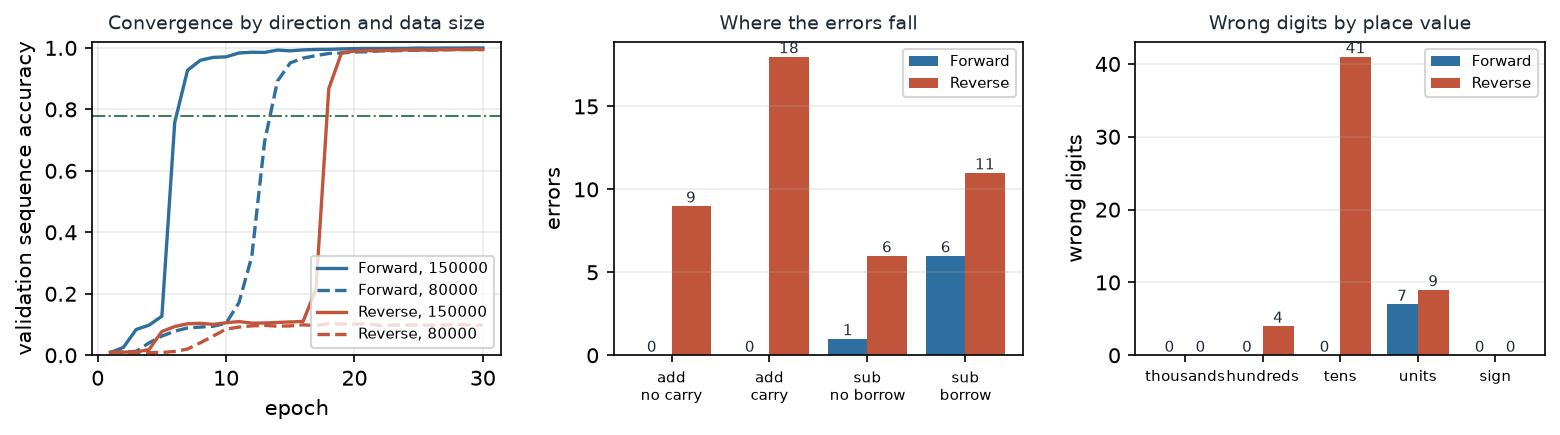

In [21]:
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"

# Figure 1 for the report. Counts rather than accuracies in the right two panels: every accuracy
# here is above 0.98, so a bar chart of rates renders the two models as identical rectangles,
# while the error counts differ by an order of magnitude and are legible.
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), dpi=150)

# Left panel: convergence. Solid is the full training set, dashed the reduced one.
ax = axes[0]
for mode, colour in [("Forward", ACCENT), ("Reverse", WARM)]:
    for size, style in [("_full", "-"), ("_80k", "--")]:
        curve = histories[(mode, size)]["val_seq"]
        label = f"{mode}, {'150000' if size == '_full' else '80000'}"
        ax.plot(range(1, len(curve) + 1), curve, style, color=colour, lw=1.6, label=label)
ax.axhline(0.78, color=GREEN, lw=1.0, ls="-.")
ax.set_xlabel("epoch")
ax.set_ylabel("validation sequence accuracy")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=7, loc="lower right")
ax.set_title("Convergence by direction and data size", fontsize=9, color=INK)

ax = axes[1]
# Two line tick labels: at the width this figure is embedded, the carry and borrow
# names collide when set on one line.
NL = chr(10)
categories = [("add" + NL + "no carry", "carry", "no_carry"),
              ("add" + NL + "carry", "carry", "with_carry"),
              ("sub" + NL + "no borrow", "borrow", "no_borrow"),
              ("sub" + NL + "borrow", "borrow", "with_borrow")]
x = np.arange(len(categories))
errors_f = [cb_f[g][k][1] - cb_f[g][k][0] for _, g, k in categories]
errors_r = [cb_r[g][k][1] - cb_r[g][k][0] for _, g, k in categories]
ax.bar(x - 0.2, errors_f, 0.4, color=ACCENT, label="Forward")
ax.bar(x + 0.2, errors_r, 0.4, color=WARM, label="Reverse")
for xi, value in zip(x - 0.2, errors_f):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=7, color=INK)
for xi, value in zip(x + 0.2, errors_r):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=7, color=INK)
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in categories], fontsize=7)
ax.set_ylabel("errors")
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=7)
ax.set_title("Where the errors fall", fontsize=9, color=INK)

ax = axes[2]
labels = ["thousands", "hundreds", "tens", "units", "sign"]
wrong_f = [round((1 - acc_f[k]) * n_f[k]) for k in labels]
wrong_r = [round((1 - acc_r[k]) * n_r[k]) for k in labels]
x = np.arange(len(labels))
ax.bar(x - 0.2, wrong_f, 0.4, color=ACCENT, label="Forward")
ax.bar(x + 0.2, wrong_r, 0.4, color=WARM, label="Reverse")
for xi, value in zip(x - 0.2, wrong_f):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=7, color=INK)
for xi, value in zip(x + 0.2, wrong_r):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=7, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("wrong digits")
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=7)
ax.set_title("Wrong digits by place value", fontsize=9, color=INK)

plt.tight_layout()
plt.savefig("figure_1_overview.pdf", bbox_inches="tight")
plt.show()

## Figure 2 for the report

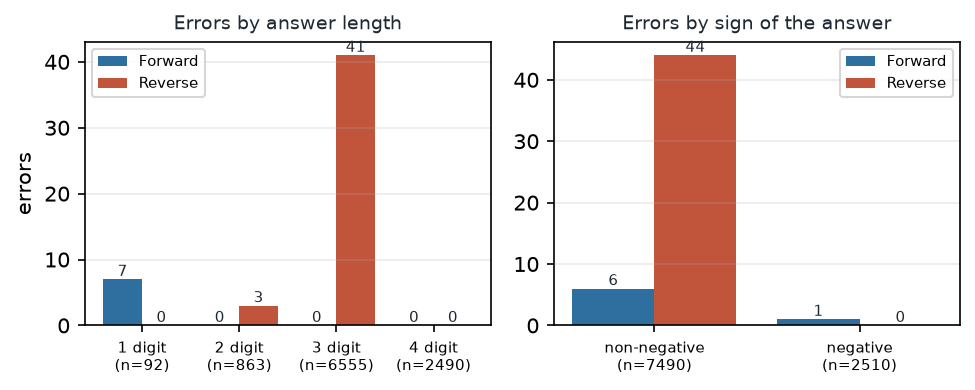

In [22]:
# Figure 2: the same errors cut by how long the answer is and whether it is negative, which is
# the axis the brief calls "longer strings".
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.7), dpi=150)

# Left panel: how long the answer is. Right panel: whether it is negative, which is the
# only case carrying a sign token and the only one reverse mode emits last.
digit_rows = [k for k in length_rows if k.endswith("digit")]
x = np.arange(len(digit_rows))
axes[0].bar(x - 0.2, [length_rows[k][1] for k in digit_rows], 0.4, color=ACCENT, label="Forward")
axes[0].bar(x + 0.2, [length_rows[k][2] for k in digit_rows], 0.4, color=WARM, label="Reverse")
for xi, k in zip(x, digit_rows):
    axes[0].text(xi - 0.2, length_rows[k][1], str(length_rows[k][1]), ha="center", va="bottom",
                 fontsize=7, color=INK)
    axes[0].text(xi + 0.2, length_rows[k][2], str(length_rows[k][2]), ha="center", va="bottom",
                 fontsize=7, color=INK)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{k}\n(n={length_rows[k][0]})" for k in digit_rows], fontsize=7)
axes[0].set_ylabel("errors")
axes[0].grid(alpha=0.25, axis="y")
axes[0].legend(fontsize=7)
axes[0].set_title("Errors by answer length", fontsize=9, color=INK)

# Counts are labelled on every bar so the figure carries its own numbers.
sign_rows = ["non-negative", "negative"]
x = np.arange(len(sign_rows))
axes[1].bar(x - 0.2, [length_rows[k][1] for k in sign_rows], 0.4, color=ACCENT, label="Forward")
axes[1].bar(x + 0.2, [length_rows[k][2] for k in sign_rows], 0.4, color=WARM, label="Reverse")
for xi, k in zip(x, sign_rows):
    axes[1].text(xi - 0.2, length_rows[k][1], str(length_rows[k][1]), ha="center", va="bottom",
                 fontsize=7, color=INK)
    axes[1].text(xi + 0.2, length_rows[k][2], str(length_rows[k][2]), ha="center", va="bottom",
                 fontsize=7, color=INK)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{k}\n(n={length_rows[k][0]})" for k in sign_rows], fontsize=7)
axes[1].grid(alpha=0.25, axis="y")
axes[1].legend(fontsize=7)
axes[1].set_title("Errors by sign of the answer", fontsize=9, color=INK)

plt.tight_layout()
plt.savefig("figure_2_by_length.pdf", bbox_inches="tight")
plt.show()

## Machine-readable summary

In [23]:
# One machine-readable dump of everything the report quotes, so tools/build_report.py can pull
# each number out by name instead of the report restating them by hand.
summary = {
    "overall": {name: {"correct": results_table[(name, "overall")][0],
                       "n": results_table[(name, "overall")][1],
                       "accuracy": results_table[(name, "overall")][2],
                       "ci": [results_table[(name, "overall")][3],
                              results_table[(name, "overall")][4]]}
                for name in ["Forward", "Reverse"]},
    "operation": {name: {split: results_table[(name, split)][2]
                         for split in ["addition", "subtraction"]}
                  for name in ["Forward", "Reverse"]},
    "positions": {"Forward": acc_f, "Reverse": acc_r, "n": n_f},
    "carry_borrow": {"Forward": cb_f, "Reverse": cb_r},
    "length": length_rows,
    "mcnemar": {"forward_only": b, "reverse_only": c, "p": p_value},
    "error_kinds": error_kinds,
    "curves": {f"{mode}{size}": curve_rows[(mode, size)] for mode, size in curve_rows},
}
print(json.dumps(summary, indent=1, default=lambda o: round(float(o), 6)))

{
 "overall": {
  "Forward": {
   "correct": 9993,
   "n": 10000,
   "accuracy": 0.9993,
   "ci": [
    0.9985556471425939,
    0.9996608779971082
   ]
  },
  "Reverse": {
   "correct": 9956,
   "n": 10000,
   "accuracy": 0.9956,
   "ci": [
    0.9940987902766892,
    0.9967205765553485
   ]
  }
 },
 "operation": {
  "Forward": {
   "addition": 1.0,
   "subtraction": 0.9985783915515841
  },
  "Reverse": {
   "addition": 0.9946808510638298,
   "subtraction": 0.9965475223395613
  }
 },
 "positions": {
  "Forward": {
   "thousands": 1.0,
   "hundreds": 1.0,
   "tens": 1.0,
   "units": 0.9993,
   "sign": 1.0
  },
  "Reverse": {
   "thousands": 1.0,
   "hundreds": 0.9995577667219459,
   "tens": 0.9958619297537343,
   "units": 0.9991,
   "sign": 1.0
  },
  "n": {
   "thousands": 2490,
   "hundreds": 9045,
   "tens": 9908,
   "units": 10000,
   "sign": 10000
  }
 },
 "carry_borrow": {
  "Forward": {
   "carry": {
    "with_carry": [
     4226,
     4226
    ],
    "no_carry": [
     850,
    